In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

## pandas - a package for data analysis and manipulation

In [2]:
# Let's generate a random dataset pretending a dataset used in recommender systems. Each row corresponds to a rating of a product
# by a user. Successive columns correspond to the time, the user id, the product id and the rating.

N = 100000

data_ = np.random.randint(1000, size=(N, 4))

df = pd.DataFrame(data_, columns=['time', 'uid', 'pid', 'rating'])
df['time'] = np.random.randint(24 * 60 * 60, size=(N))
df['time'] = pd.to_datetime('2025-01-01') + pd.to_timedelta(1e9 * df['time'])
df['rating'] = np.random.randint(10, size=(N))

df.head()

,time,uid,pid,rating
0,2025-01-01 10:37:04,57,153,6
1,2025-01-01 08:59:10,33,822,8
2,2025-01-01 12:35:02,831,939,1
3,2025-01-01 18:15:28,146,8,0
4,2025-01-01 22:47:15,919,729,1


pid
911    135
275    132
690    127
428    127
384    127
897    126
735    126
512    126
35     125
248    125
756    124
992    124
487    124
551    123
89     123
290    123
603    123
660    122
56     122
762    122
741    122
273    122
907    122
802    121
58     121
Name: count, dtype: int64

<Axes: >

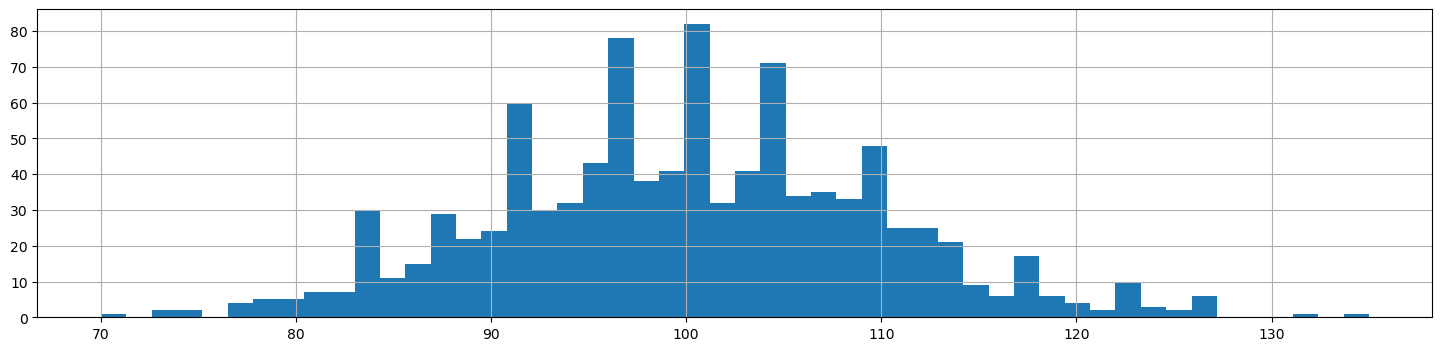

In [3]:
# Let's see the 25 most popular products in the dataset. Let's make a histogram of the product popularity.

df_ = df['pid'].value_counts()

display(df_.head(25))

df_.hist(figsize=(18, 4), bins=50)

In [4]:
# Let's prepare a sub-dataset that keeps only the 100 most popular products in the dataset and removes the others.

df_ = df['pid'].value_counts()

pids = df_.index[:100]

df_preprocessed = df[df['pid'].isin(pids)]
df_preprocessed

,time,uid,pid,rating
2,2025-01-01 12:35:02,831,939,1
7,2025-01-01 07:43:55,330,880,3
30,2025-01-01 08:20:13,209,276,0
41,2025-01-01 11:12:28,671,735,0
57,2025-01-01 16:17:16,81,102,4
...,...,...,...,...
99949,2025-01-01 21:14:16,592,401,1
99954,2025-01-01 09:21:12,513,812,2
99960,2025-01-01 12:07:25,992,286,3
99963,2025-01-01 01:18:06,456,310,1


In [5]:
# Let's see what is the mean of ratings given by each user (which may be interpreted as the user baseline rating or a type of
# the user optimism level).

df.groupby('uid')['rating'].mean().to_frame()

,rating
uid,
0,3.822430
1,4.272000
2,4.610000
3,4.770000
4,4.232143
...,...
995,4.702381
996,4.460784
997,4.590909


In [6]:
# Let's make the matrix of ratings, where columns correspond to products, rows correspond to users, and the values are the
# ratings (in fact, means of ratings, if an user rated a product multiple times).
# REMARK: Such a dataframe may require a large amount of memory. In practice, try to avoid it.

df.groupby(['uid', 'pid'])['rating'].mean().unstack().fillna(0.0)

pid,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
uid,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,5.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,...,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,4.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
997,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Let's see what is the mean of ratings in the entire system in successive hours during the day, from 8 a.m to 4 p.m.

df.set_index('time').between_time('8:00', '16:00').resample('1h')['rating'].mean().to_frame()

,rating
time,
2025-01-01 08:00:00,4.519328
2025-01-01 09:00:00,4.533880
2025-01-01 10:00:00,4.519190
2025-01-01 11:00:00,4.473084
2025-01-01 12:00:00,4.456169
2025-01-01 13:00:00,4.506362
2025-01-01 14:00:00,4.545960
2025-01-01 15:00:00,4.499156
2025-01-01 16:00:00,4.666667


time,2025-01-01 00:00:00,2025-01-01 01:00:00,2025-01-01 02:00:00,2025-01-01 03:00:00,2025-01-01 04:00:00,2025-01-01 05:00:00,2025-01-01 06:00:00,2025-01-01 07:00:00,2025-01-01 08:00:00,2025-01-01 09:00:00,...,2025-01-01 14:00:00,2025-01-01 15:00:00,2025-01-01 16:00:00,2025-01-01 17:00:00,2025-01-01 18:00:00,2025-01-01 19:00:00,2025-01-01 20:00:00,2025-01-01 21:00:00,2025-01-01 22:00:00,2025-01-01 23:00:00
uid,,,,,,,,,,,,,,,,,,,,,
0,3.400000,2.500000,3.600000,6.333333,4.000000,4.285714,3.200000,2.666667,2.000000,2.800000,...,5.500000,3.400000,3.500000,2.800000,5.333333,4.750000,2.800000,5.000000,5.400000,3.750000
1,5.100000,5.090909,3.600000,0.000000,3.666667,4.666667,4.500000,5.428571,3.750000,4.142857,...,5.000000,4.500000,4.000000,2.000000,3.833333,5.000000,2.250000,5.000000,3.750000,4.500000
2,3.000000,5.333333,0.500000,3.666667,5.200000,5.750000,4.200000,5.166667,5.500000,3.250000,...,5.333333,6.400000,4.600000,8.250000,3.857143,0.000000,3.750000,4.000000,4.000000,4.571429
3,3.666667,8.500000,1.500000,4.333333,5.200000,5.333333,5.800000,4.200000,3.750000,5.500000,...,3.333333,5.750000,4.000000,5.000000,3.000000,5.200000,7.000000,4.500000,4.000000,5.833333
4,5.500000,5.750000,3.600000,4.000000,2.333333,3.125000,2.333333,5.333333,4.333333,3.200000,...,4.000000,5.666667,2.750000,3.400000,5.714286,4.125000,3.666667,5.000000,5.500000,4.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3.000000,5.500000,3.000000,5.555556,5.500000,1.000000,7.666667,3.500000,2.500000,3.500000,...,4.666667,4.000000,3.000000,5.750000,8.333333,3.500000,4.333333,1.500000,5.200000,7.333333
996,1.500000,4.375000,4.428571,6.000000,4.750000,3.666667,5.000000,5.500000,1.500000,4.142857,...,3.333333,5.000000,6.400000,5.666667,4.333333,5.333333,3.666667,3.666667,5.000000,3.500000
997,4.500000,4.000000,2.000000,4.600000,3.750000,5.250000,3.000000,0.000000,4.250000,2.000000,...,5.500000,3.571429,3.666667,6.000000,6.125000,2.777778,6.000000,5.272727,3.333333,4.000000


<Axes: xlabel='time'>

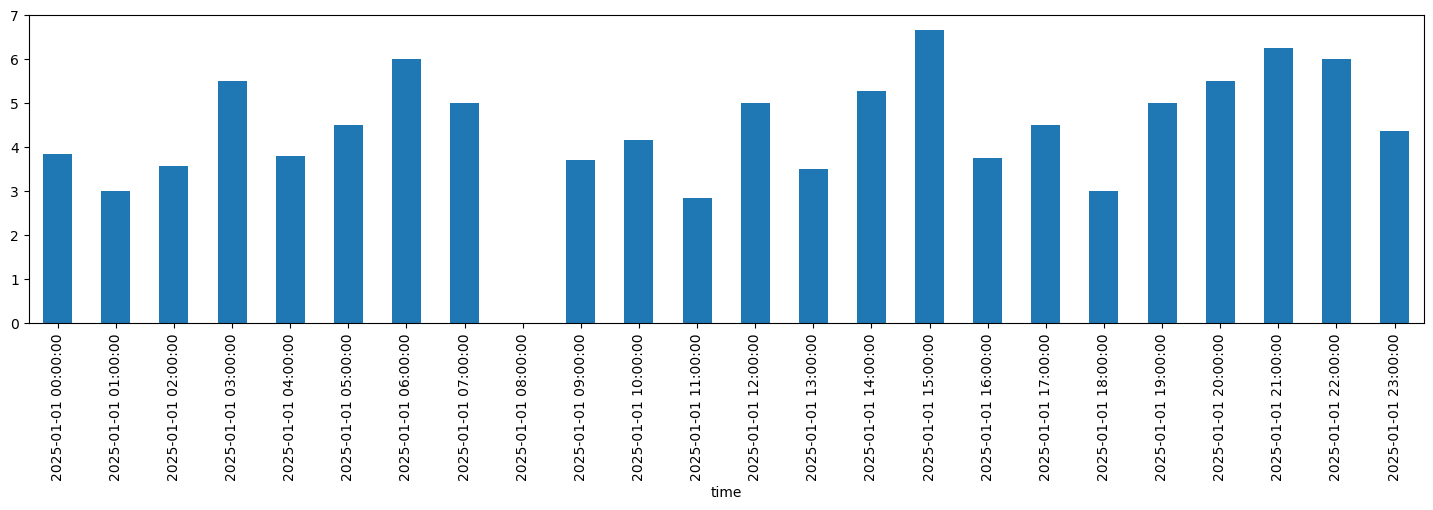

In [8]:
# Let's see what is the mean of ratings given by each user in successive hours during the day (which may be interpreted as the
# change of mood of each user during the day). Let's plot this a random user.

df_ = df.set_index('time').groupby('uid').resample('1h')['rating'].mean().unstack().fillna(0.0)

display(df_)

df_.loc[25].plot(figsize=(18, 4), kind='bar')

In [9]:
# Let's make a sequence of products rated by each user. This pretends a dataset used in sequential or session-based recommender
# systems.

df.set_index('time').sort_index().groupby('uid')['pid'].agg(list)

uid
0      [217, 743, 290, 470, 233, 561, 182, 114, 507, ...
1      [323, 454, 865, 687, 339, 579, 917, 373, 622, ...
2      [716, 854, 481, 333, 83, 812, 247, 517, 398, 1...
3      [108, 212, 30, 970, 93, 328, 290, 330, 842, 38...
4      [699, 22, 403, 571, 950, 130, 244, 361, 188, 2...
                             ...                        
995    [609, 909, 411, 816, 705, 361, 635, 211, 953, ...
996    [27, 311, 557, 731, 739, 835, 990, 597, 489, 5...
997    [632, 120, 224, 174, 29, 287, 915, 73, 945, 15...
998    [167, 945, 230, 170, 756, 650, 86, 811, 40, 58...
999    [488, 458, 932, 409, 388, 0, 698, 714, 12, 528...
Name: pid, Length: 1000, dtype: object

In [10]:
# Let's create product names and add them to the dataset.
# REMARK: Yes. This is very inefficient - the data are redundant. It would be better to store the product names in a separate
# dataframe indexed by the product id (a type of a dictionary). But I would like to demonstrate here the map() method and the
# lambda expression.

df['product_name'] = df['pid'].map(lambda x: 'Product No. %04d' % x).rename('Product Name')
df

,time,uid,pid,rating,product_name
0,2025-01-01 10:37:04,57,153,6,Product No. 0153
1,2025-01-01 08:59:10,33,822,8,Product No. 0822
2,2025-01-01 12:35:02,831,939,1,Product No. 0939
3,2025-01-01 18:15:28,146,8,0,Product No. 0008
4,2025-01-01 22:47:15,919,729,1,Product No. 0729
...,...,...,...,...,...
99995,2025-01-01 03:43:34,538,693,0,Product No. 0693
99996,2025-01-01 02:13:35,633,968,3,Product No. 0968
99997,2025-01-01 15:40:41,915,357,0,Product No. 0357
99998,2025-01-01 19:47:42,852,482,1,Product No. 0482


In [11]:
# Let's evaluate the mean of ratings given by each user and subtract it from each rating of the user (which makes the rating
# more fair, independent of the user baseline rating)

df1 = df.groupby('uid')['rating'].mean().rename('user_mean_rating').to_frame()

df_u = df.join(df1['user_mean_rating'], how='left', on='uid')
df_u['rating'] = df_u['rating'] - df_u['user_mean_rating']
df_u

,time,uid,pid,rating,product_name,user_mean_rating
0,2025-01-01 10:37:04,57,153,1.627119,Product No. 0153,4.372881
1,2025-01-01 08:59:10,33,822,4.330097,Product No. 0822,3.669903
2,2025-01-01 12:35:02,831,939,-3.947368,Product No. 0939,4.947368
3,2025-01-01 18:15:28,146,8,-4.657658,Product No. 0008,4.657658
4,2025-01-01 22:47:15,919,729,-3.527473,Product No. 0729,4.527473
...,...,...,...,...,...,...
99995,2025-01-01 03:43:34,538,693,-4.414634,Product No. 0693,4.414634
99996,2025-01-01 02:13:35,633,968,-1.659091,Product No. 0968,4.659091
99997,2025-01-01 15:40:41,915,357,-4.073171,Product No. 0357,4.073171
99998,2025-01-01 19:47:42,852,482,-3.958678,Product No. 0482,4.958678


In [12]:
# Let's evaluate the mean of ratings given to each product and subtract it from each rating of the product (which makes the
# rating more fair, independent of the product baseline rating)

df2 = df.groupby('pid')['rating'].mean().rename('product_mean_rating').to_frame()

df_p = df.join(df2['product_mean_rating'], how='left', on='pid')
df_p['rating'] = df_p['rating'] - df_p['product_mean_rating']
df_p

,time,uid,pid,rating,product_name,product_mean_rating
0,2025-01-01 10:37:04,57,153,1.237624,Product No. 0153,4.762376
1,2025-01-01 08:59:10,33,822,3.680851,Product No. 0822,4.319149
2,2025-01-01 12:35:02,831,939,-3.157895,Product No. 0939,4.157895
3,2025-01-01 18:15:28,146,8,-4.916667,Product No. 0008,4.916667
4,2025-01-01 22:47:15,919,729,-3.516484,Product No. 0729,4.516484
...,...,...,...,...,...,...
99995,2025-01-01 03:43:34,538,693,-4.141414,Product No. 0693,4.141414
99996,2025-01-01 02:13:35,633,968,-1.191011,Product No. 0968,4.191011
99997,2025-01-01 15:40:41,915,357,-4.131313,Product No. 0357,4.131313
99998,2025-01-01 19:47:42,852,482,-3.267442,Product No. 0482,4.267442


<Axes: >

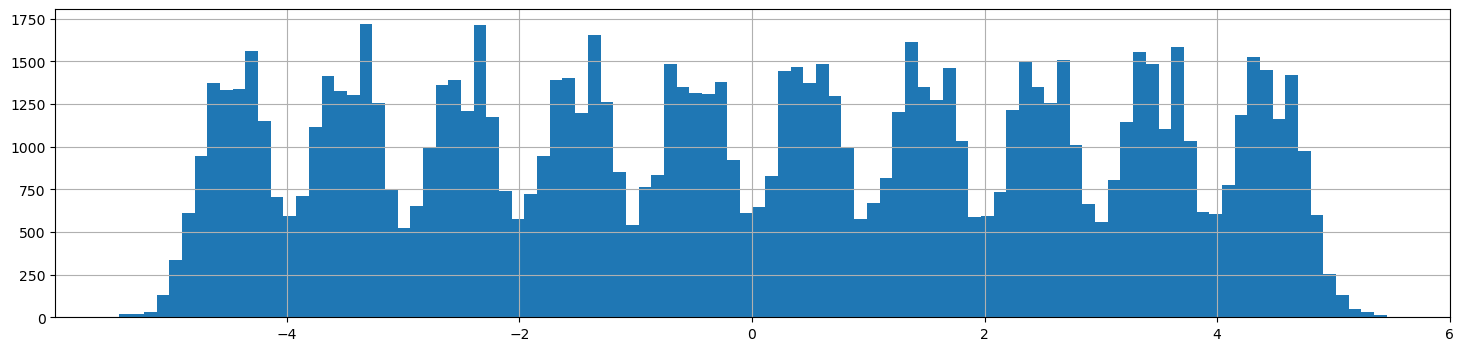

In [13]:
# Let's make a histogram of such relative ratings in the dataset.

df_p['rating'].hist(figsize=(18, 4), bins=100)

,product_rating_std
pid,
0,2.899079
1,2.740112
2,2.932706
3,2.912748
4,2.709709
...,...
995,2.850257
996,2.851073
997,2.839609


<Axes: >

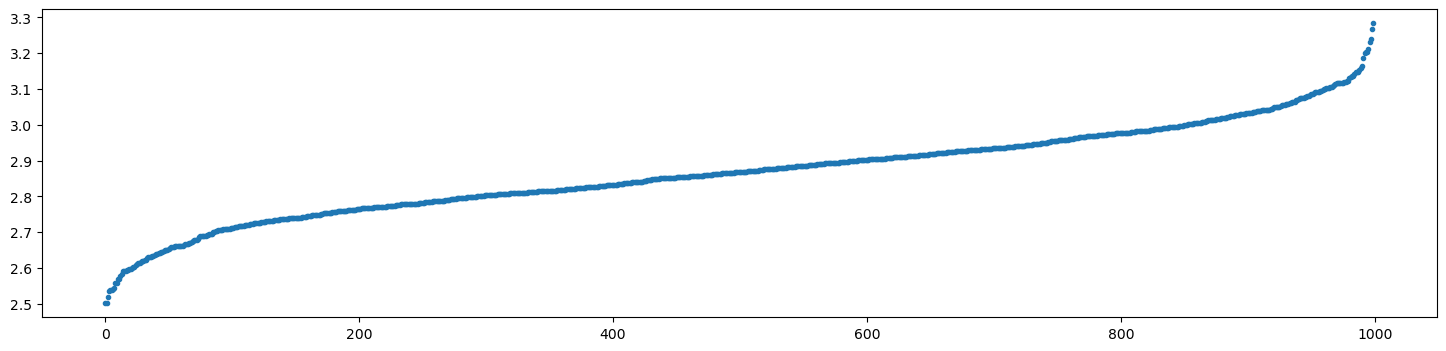

In [14]:
# Let's look at how stable the product ratings are.

df_ = df.groupby('pid')['rating'].std().rename('product_rating_std').to_frame()
display(df_)

df_['product_rating_std'].sort_values().reset_index(drop=True).plot(figsize=(18, 4), linestyle='', marker='.')

In [15]:
# Let's divide the products into 10 groups in terms of the stability of product ratings.

pd.cut(df_['product_rating_std'], bins=10, labels=False).to_frame()

,product_rating_std
pid,
0,5
1,3
2,5
3,5
4,2
...,...
995,4
996,4
997,4


## dask - a package for remote and/or distributed data analysis and manipulation

This notebook uses a data source being a simple .csv file, just for demonstration purposes, but in practice such data sources usually represent connections to remote and/or distributed databases where dask enables remote data analysis and manipulation without downloading big amounts of data.

In [16]:
import dask.dataframe as dd

/Users/mariaszlasa/miniconda3/lib/python3.11/site-packages/dask/dataframe/_pyarrow_compat.py:15: FutureWarning: Minimal version of pyarrow will soon be increased to 14.0.1. You are using 11.0.0. Please consider upgrading.
  warnings.warn(


In [17]:
df.to_csv('tutorial_dataset.csv', index=False)

df = dd.read_csv('tutorial_dataset.csv')
df.head()

,time,uid,pid,rating,product_name
0,2025-01-01 10:37:04,57,153,6,Product No. 0153
1,2025-01-01 08:59:10,33,822,8,Product No. 0822
2,2025-01-01 12:35:02,831,939,1,Product No. 0939
3,2025-01-01 18:15:28,146,8,0,Product No. 0008
4,2025-01-01 22:47:15,919,729,1,Product No. 0729


In [18]:
df1 = df.groupby('uid')['rating'].mean().to_frame()
df1

,rating
npartitions=1,
,float64
,...


In [19]:
df1.compute()

,rating
uid,
0,3.822430
1,4.272000
2,4.610000
3,4.770000
4,4.232143
...,...
995,4.702381
996,4.460784
997,4.590909


In [20]:
df2 = df
df2['uid_random'] = np.random.randint(len(df2))

In [21]:
df2.persist()

,time,uid,pid,rating,product_name,uid_random
npartitions=1,,,,,,
,object,int64,int64,int64,object,int64
,...,...,...,...,...,...
